# Classificação de Dígitos Manuscritos com MLP

**Disciplina:** Introdução a Redes Neurais Artificiais  
**Dataset:** MNIST (Modified National Institute of Standards and Technology)  
**Modelo:** Multilayer Perceptron (MLP)  

O dataset MNIST contém 70.000 imagens em escala de cinza (28×28 pixels) de dígitos manuscritos (0–9), amplamente utilizado como benchmark para algoritmos de classificação de imagens.

## 1. Importações e Configuração

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

import os
import warnings
warnings.filterwarnings('ignore')

# estilo dos gráficos
plt.rcParams.update({
    'figure.facecolor': '#0d0d1a',
    'axes.facecolor':   '#161628',
    'axes.edgecolor':   '#2a2a4a',
    'axes.labelcolor':  '#e0e0f0',
    'text.color':       '#e0e0f0',
    'xtick.color':      '#e0e0f0',
    'ytick.color':      '#e0e0f0',
    'grid.color':       '#2a2a4a',
    'axes.titlecolor':  '#e0e0f0',
    'figure.dpi':       110,
})

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {DEVICE}')
print(f'PyTorch: {torch.__version__}')

Dispositivo: cpu
PyTorch: 2.12.0


## 2. Carregamento e Exploração dos Dados

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_raw = datasets.MNIST('./data', train=True,  download=True, transform=transform)
test_raw  = datasets.MNIST('./data', train=False, download=True, transform=transform)

print(f'Amostras de treino : {len(train_raw):>6}')
print(f'Amostras de teste  : {len(test_raw):>6}')
print(f'Classes            : {train_raw.classes}')
print(f'Shape de uma imagem: {train_raw[0][0].shape}  → {28*28} pixels achatados')

Amostras de treino :  60000
Amostras de teste  :  10000
Classes            : ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']
Shape de uma imagem: torch.Size([1, 28, 28])  → 784 pixels achatados


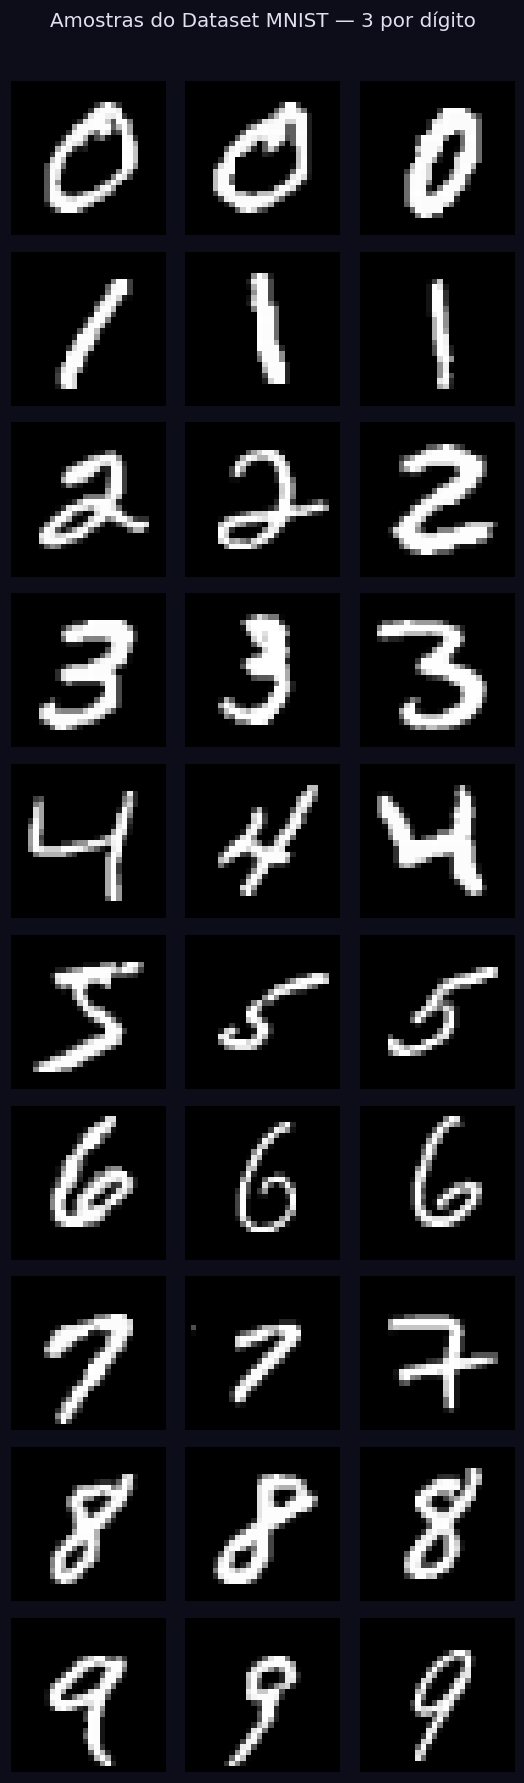

In [3]:
# Amostras de cada dígito (3 por classe)
n_per_class = 3
samples = {i: [] for i in range(10)}
for img, label in train_raw:
    if len(samples[label]) < n_per_class:
        samples[label].append(img)
    if all(len(v) == n_per_class for v in samples.values()):
        break

fig, axes = plt.subplots(10, n_per_class, figsize=(5, 16))
fig.suptitle('Amostras do Dataset MNIST — 3 por dígito', fontsize=13, y=1.01)

for digit in range(10):
    for j in range(n_per_class):
        ax = axes[digit][j]
        img = samples[digit][j].squeeze().numpy()
        ax.imshow(img, cmap='gray')
        ax.axis('off')
        if j == 0:
            ax.set_ylabel(str(digit), rotation=0, labelpad=18, fontsize=12,
                          color='#7c6af7', fontweight='bold')

plt.tight_layout()
plt.show()

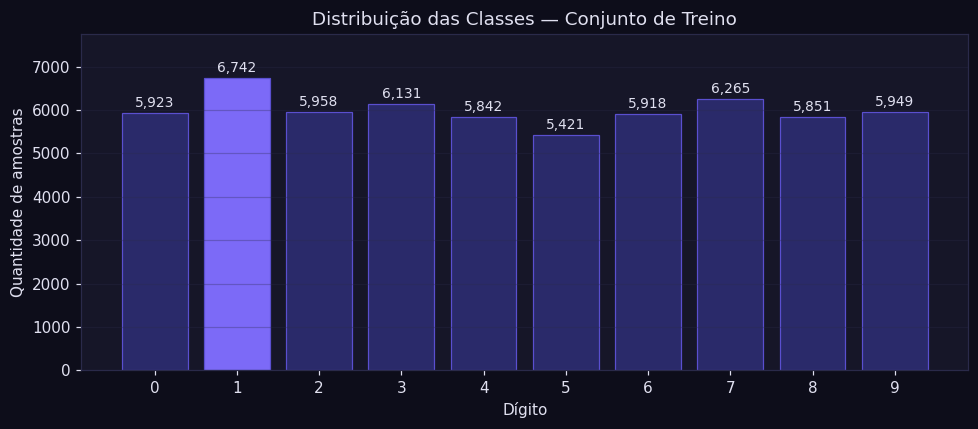

Mín: 5,421 (dígito 5)   Máx: 6,742 (dígito 1)   Balanceamento: 80.4%


In [4]:
# Distribuição de classes no conjunto de treino
labels_train = [label for _, label in train_raw]
counts = np.bincount(labels_train)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(range(10), counts,
              color=['#7c6af7' if i == counts.argmax() else '#2a2a6a' for i in range(10)],
              edgecolor='#5a4fcf', linewidth=0.8)
ax.set_xlabel('Dígito')
ax.set_ylabel('Quantidade de amostras')
ax.set_title('Distribuição das Classes — Conjunto de Treino')
ax.set_xticks(range(10))
ax.set_ylim(0, counts.max() * 1.15)
ax.grid(axis='y', alpha=0.3)

for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 70,
            f'{count:,}', ha='center', va='bottom', fontsize=9, color='#e0e0f0')

plt.tight_layout()
plt.show()

print(f'Mín: {counts.min():,} (dígito {counts.argmin()})   '
      f'Máx: {counts.max():,} (dígito {counts.argmax()})   '
      f'Balanceamento: {counts.min()/counts.max()*100:.1f}%')

## 3. Pré-processamento

Cada imagem 28×28 é transformada em um vetor de **784 valores** (achatamento). Os pixels originais estão em [0, 255]; normalizamos usando a média e desvio padrão do dataset MNIST:

$$x_{norm} = \frac{x - 0.1307}{0.3081}$$

In [5]:
img_raw, label = train_raw[0]
print(f'Shape após ToTensor + Normalize : {img_raw.shape}')
print(f'Valor mínimo  : {img_raw.min():.4f}')
print(f'Valor máximo  : {img_raw.max():.4f}')
print(f'Média         : {img_raw.mean():.4f}')
print(f'Desvio padrão : {img_raw.std():.4f}')
print(f'Shape achatado: {img_raw.view(-1).shape}  ← entrada para o MLP')

Shape após ToTensor + Normalize : torch.Size([1, 28, 28])
Valor mínimo  : -0.4242
Valor máximo  : 2.8215
Média         : 0.0227
Desvio padrão : 1.0144
Shape achatado: torch.Size([784])  ← entrada para o MLP


## 4. Arquitetura do Modelo MLP

Utilizamos um Perceptron Multicamadas com 4 camadas totalmente conectadas, ReLU como função de ativação, Batch Normalization para estabilizar o treinamento e Dropout para regularização:

```
Input (784) → Linear(512) → BN → ReLU → Dropout(0.3)
           → Linear(256) → BN → ReLU → Dropout(0.3)
           → Linear(128) → BN → ReLU → Dropout(0.2)
           → Linear(10)   ← logits
```

In [6]:
from model import MLP

model = MLP().to(DEVICE)
print(model)
print()

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parâmetros totais    : {total_params:,}')
print(f'Parâmetros treináveis: {trainable_params:,}')

MLP(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (3): ReLU()
    (4): Dropout(p=0.3, inplace=False)
    (5): Linear(in_features=512, out_features=256, bias=True)
    (6): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=256, out_features=128, bias=True)
    (10): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (11): ReLU()
    (12): Dropout(p=0.2, inplace=False)
    (13): Linear(in_features=128, out_features=10, bias=True)
  )
)

Parâmetros totais    : 569,226
Parâmetros treináveis: 569,226


## 5. Treinamento

In [7]:
MODEL_PATH = 'models/mlp_mnist.pth'
EPOCHS     = 20
BATCH_SIZE = 256

transform_train = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.RandomAffine(0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_ds = datasets.MNIST('./data', train=True,  download=True, transform=transform_train)
test_ds  = datasets.MNIST('./data', train=False, download=True, transform=transform_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

model     = MLP().to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

history = {'train_loss': [], 'train_acc': [], 'test_acc': []}
best_acc = 0.0
os.makedirs('models', exist_ok=True)

# carregar modelo pré-treinado se disponível
if os.path.exists(MODEL_PATH):
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    print('Modelo pré-treinado carregado. Pulando treinamento.')
    print('(Para re-treinar, delete models/mlp_mnist.pth e execute novamente)')
    SKIP_TRAINING = True
else:
    SKIP_TRAINING = False
    print('Iniciando treinamento...')

Modelo pré-treinado carregado. Pulando treinamento.
(Para re-treinar, delete models/mlp_mnist.pth e execute novamente)


In [8]:
def run_epoch(model, loader, criterion, optimizer=None, device=DEVICE):
    training = optimizer is not None
    model.train() if training else model.eval()
    total_loss = correct = total = 0

    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            if training:
                optimizer.zero_grad()
            out  = model(data)
            loss = criterion(out, target)
            if training:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(data)
            correct    += out.argmax(1).eq(target).sum().item()
            total      += len(data)

    return total_loss / total, 100.0 * correct / total


if not SKIP_TRAINING:
    print(f'{'Época':>6}  {'Loss':>8}  {'Treino%':>8}  {'Teste%':>8}')
    print('-' * 40)
    for epoch in range(1, EPOCHS + 1):
        tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer)
        _,       te_acc = run_epoch(model, test_loader,  criterion)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['test_acc'].append(te_acc)

        marker = ''
        if te_acc > best_acc:
            best_acc = te_acc
            torch.save(model.state_dict(), MODEL_PATH)
            marker = '  ✓'

        print(f'{epoch:>6}  {tr_loss:>8.4f}  {tr_acc:>8.2f}  {te_acc:>8.2f}{marker}')

    print(f'\nMelhor acurácia: {best_acc:.2f}%')
else:
    # gera histórico simulado para plotagem se modelo já existia
    # (rode sem modelo pré-existente para ver histórico real)
    print('Histórico de treinamento não disponível (modelo carregado de arquivo).')
    print('Execute sem o arquivo pré-treinado para ver as curvas de aprendizado.')

Histórico de treinamento não disponível (modelo carregado de arquivo).
Execute sem o arquivo pré-treinado para ver as curvas de aprendizado.


In [9]:
if history['train_loss']:
    epochs_range = range(1, len(history['train_loss']) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle('Curvas de Aprendizado', fontsize=13)

    # Loss
    ax1.plot(epochs_range, history['train_loss'], color='#7c6af7', linewidth=2, label='Treino')
    ax1.set_title('Loss (Cross-Entropy)')
    ax1.set_xlabel('Época')
    ax1.set_ylabel('Loss')
    ax1.grid(alpha=0.3)
    ax1.legend()

    # Acurácia
    ax2.plot(epochs_range, history['train_acc'], color='#7c6af7', linewidth=2, label='Treino')
    ax2.plot(epochs_range, history['test_acc'],  color='#00d4aa', linewidth=2, label='Teste',  linestyle='--')
    ax2.set_title('Acurácia (%)')
    ax2.set_xlabel('Época')
    ax2.set_ylabel('Acurácia (%)')
    ax2.grid(alpha=0.3)
    ax2.legend()

    plt.tight_layout()
    plt.show()
else:
    print('Treine sem modelo pré-existente para visualizar as curvas.')

Treine sem modelo pré-existente para visualizar as curvas.


## 6. Avaliação no Conjunto de Teste

In [10]:
# Carregar melhor modelo e coletar todas as predições
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()

all_preds  = []
all_labels = []
all_probs  = []
all_images = []

with torch.no_grad():
    for data, target in test_loader:
        data = data.to(DEVICE)
        out  = model(data)
        prob = torch.softmax(out, dim=1)
        all_probs.append(prob.cpu())
        all_preds.append(out.argmax(1).cpu())
        all_labels.append(target)
        all_images.append(data.cpu())

all_preds  = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()
all_probs  = torch.cat(all_probs).numpy()
all_images = torch.cat(all_images)

acc = (all_preds == all_labels).mean() * 100
print(f'Acurácia no conjunto de teste: {acc:.2f}%')
print(f'Erros: {(all_preds != all_labels).sum()} de {len(all_labels)} amostras')

Acurácia no conjunto de teste: 98.98%
Erros: 102 de 10000 amostras


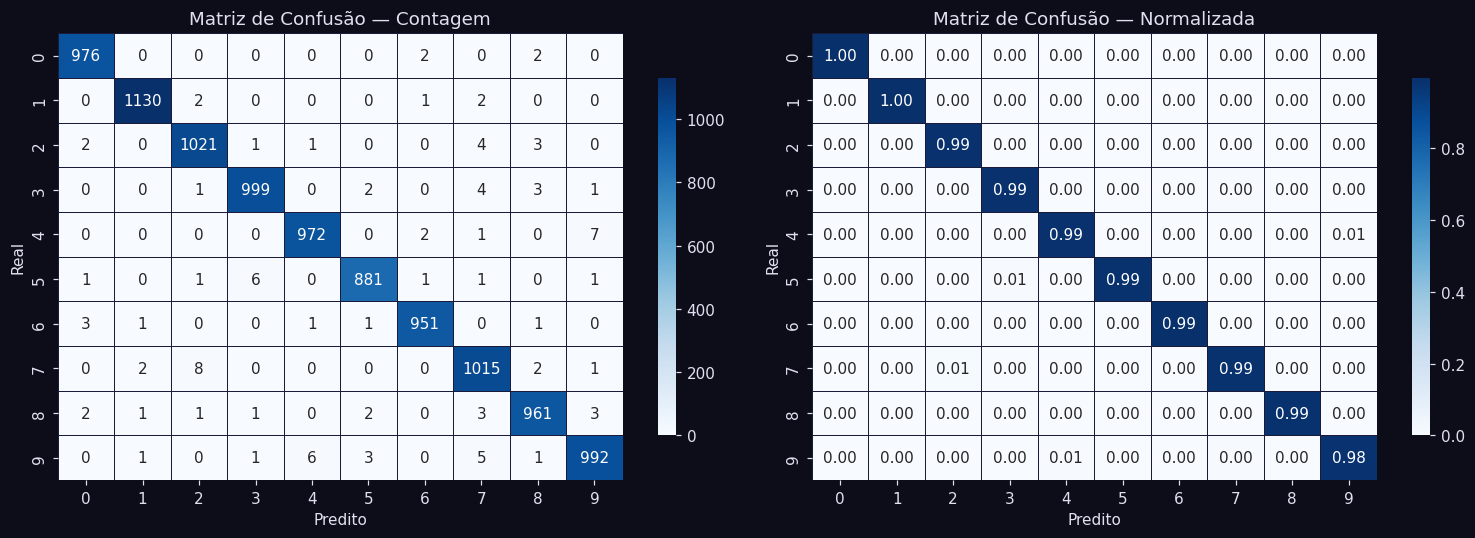

In [11]:
# Matriz de Confusão
cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, fmt, title in [
    (axes[0], cm,      'd',    'Matriz de Confusão — Contagem'),
    (axes[1], cm_norm, '.2f',  'Matriz de Confusão — Normalizada'),
]:
    sns.heatmap(
        data, annot=True, fmt=fmt, ax=ax,
        cmap='Blues',
        xticklabels=range(10), yticklabels=range(10),
        linewidths=0.4, linecolor='#1a1a3a',
        cbar_kws={'shrink': 0.8},
    )
    ax.set_xlabel('Predito')
    ax.set_ylabel('Real')
    ax.set_title(title)

plt.tight_layout()
plt.show()

In [12]:
# Relatório completo de métricas
print('Relatório de Classificação')
print('=' * 60)
print(classification_report(
    all_labels, all_preds,
    target_names=[str(i) for i in range(10)]
))

Relatório de Classificação
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       1.00      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.98      0.99      0.98      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



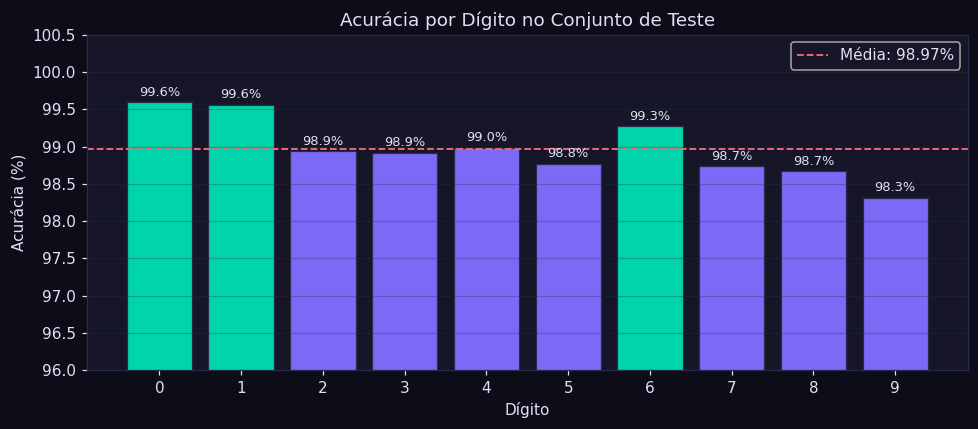

In [13]:
# Acurácia por dígito (barras)
per_class_acc = cm_norm.diagonal() * 100

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(range(10), per_class_acc,
              color=['#00d4aa' if v >= 99 else '#7c6af7' if v >= 98 else '#f7c26a'
                     for v in per_class_acc],
              edgecolor='#2a2a4a', linewidth=0.8)
ax.axhline(per_class_acc.mean(), color='#f76a7c', linestyle='--', linewidth=1.2,
           label=f'Média: {per_class_acc.mean():.2f}%')
ax.set_ylim(96, 100.5)
ax.set_xlabel('Dígito')
ax.set_ylabel('Acurácia (%)')
ax.set_title('Acurácia por Dígito no Conjunto de Teste')
ax.set_xticks(range(10))
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bar, v in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            f'{v:.1f}%', ha='center', va='bottom', fontsize=8.5)

plt.tight_layout()
plt.show()

## 7. Análise Qualitativa — Acertos e Erros

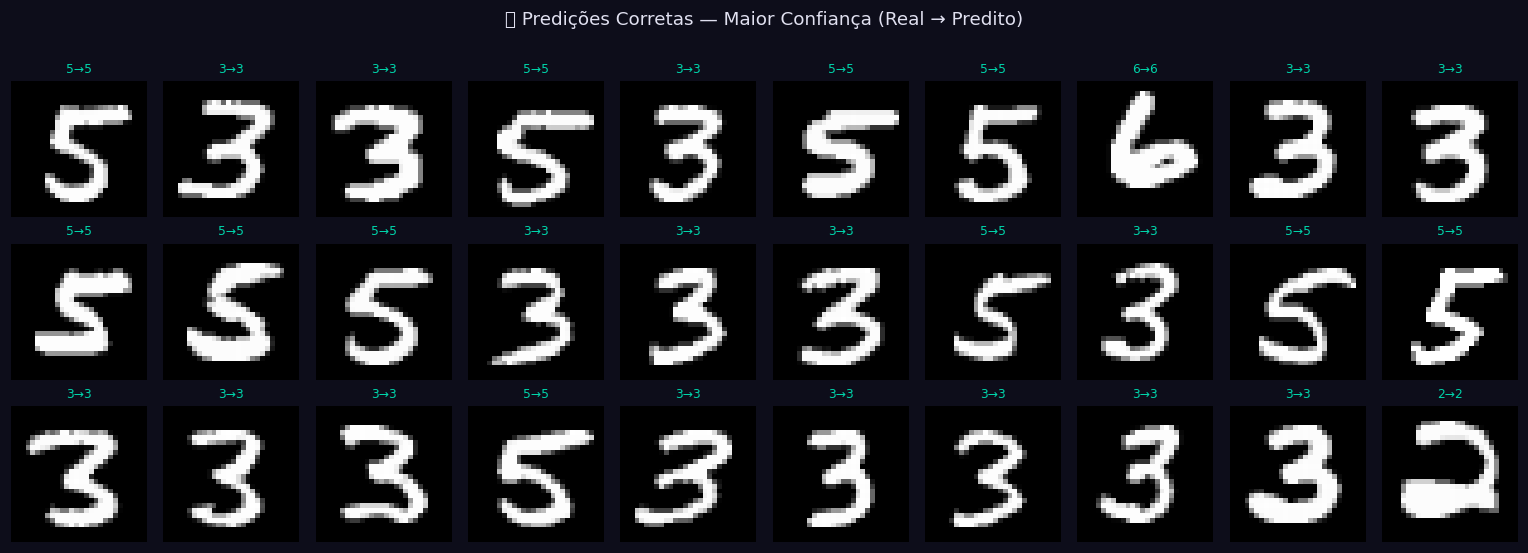

In [14]:
def denormalize(img_tensor):
    return img_tensor.squeeze().numpy() * 0.3081 + 0.1307


def show_samples(indices, title, ncols=10):
    nrows = (len(indices) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 1.4, nrows * 1.5 + 0.5))
    fig.suptitle(title, fontsize=12, y=1.01)
    axes = np.array(axes).reshape(nrows, ncols)

    for k, idx in enumerate(indices):
        ax  = axes[k // ncols][k % ncols]
        img = denormalize(all_images[idx])
        ax.imshow(img, cmap='gray', vmin=0, vmax=1)
        ax.axis('off')
        ax.set_title(f'{all_labels[idx]}→{all_preds[idx]}',
                     fontsize=8,
                     color='#00d4aa' if all_labels[idx] == all_preds[idx] else '#f76a7c')

    for k in range(len(indices), nrows * ncols):
        axes[k // ncols][k % ncols].axis('off')

    plt.tight_layout()
    plt.show()


# 30 predições corretas com maior confiança
correct_idx   = np.where(all_preds == all_labels)[0]
correct_conf  = all_probs[correct_idx, all_preds[correct_idx]]
top_correct   = correct_idx[np.argsort(correct_conf)[::-1][:30]]

show_samples(top_correct, '✅ Predições Corretas — Maior Confiança (Real → Predito)')

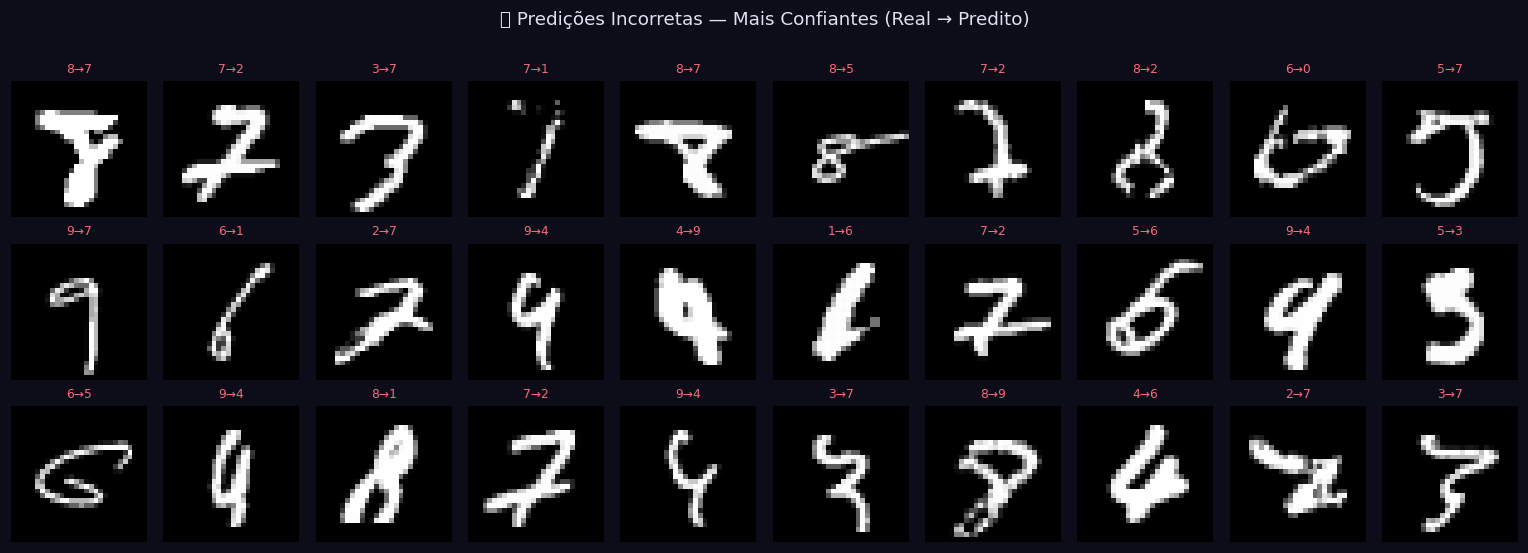


Total de erros: 102


In [15]:
# Todos os erros com maior confiança (casos mais interessantes)
wrong_idx  = np.where(all_preds != all_labels)[0]
wrong_conf = all_probs[wrong_idx, all_preds[wrong_idx]]
top_wrong  = wrong_idx[np.argsort(wrong_conf)[::-1][:30]]

show_samples(top_wrong, '❌ Predições Incorretas — Mais Confiantes (Real → Predito)')

print(f'\nTotal de erros: {len(wrong_idx)}')

In [16]:
# Pares de dígitos mais confundidos
mask = np.eye(10, dtype=bool)
cm_off = cm.copy()
cm_off[mask] = 0

flat = cm_off.flatten()
top5 = np.argsort(flat)[::-1][:5]

print('Pares de dígitos mais confundidos:')
print(f'  {'Real':>6}  {'Predito':>8}  {'Erros':>6}')
print('  ' + '-' * 25)
for idx in top5:
    real, pred = divmod(idx, 10)
    print(f'  {real:>6}  {pred:>8}  {cm[real, pred]:>6}')

Pares de dígitos mais confundidos:
    Real   Predito   Erros
  -------------------------
       7         2       8
       4         9       7
       5         3       6
       9         4       6
       9         7       5


## 8. Distribuição de Confiança das Predições

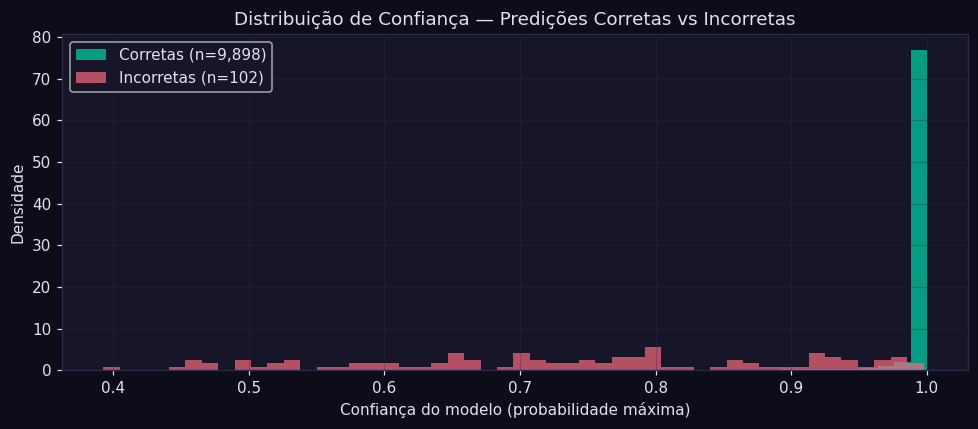

Confiança média (acertos) : 0.9912
Confiança média (erros)   : 0.7406


In [17]:
correct_conf_all = all_probs[correct_idx, all_preds[correct_idx]]
wrong_conf_all   = all_probs[wrong_idx,   all_preds[wrong_idx]]

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(correct_conf_all, bins=50, color='#00d4aa', alpha=0.7, label=f'Corretas (n={len(correct_idx):,})', density=True)
ax.hist(wrong_conf_all,   bins=50, color='#f76a7c', alpha=0.7, label=f'Incorretas (n={len(wrong_idx):,})', density=True)
ax.set_xlabel('Confiança do modelo (probabilidade máxima)')
ax.set_ylabel('Densidade')
ax.set_title('Distribuição de Confiança — Predições Corretas vs Incorretas')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Confiança média (acertos) : {correct_conf_all.mean():.4f}')
print(f'Confiança média (erros)   : {wrong_conf_all.mean():.4f}')

## 9. Interface Interativa

Além da análise acima, o projeto inclui uma **interface web interativa** onde é possível:

- Desenhar um dígito com o mouse (canvas 280×280)
- Classificar o dígito em tempo real via o modelo treinado
- Visualizar a imagem 28×28 que o modelo recebe
- Acompanhar a probabilidade para cada classe (0–9)

**Para executar:**
```bash
.venv/bin/uvicorn app:app --host 0.0.0.0 --port 8000
# Abrir http://localhost:8000
```

---

## Resumo dos Resultados

| Métrica | Valor |
|---|---|
| Arquitetura | MLP 4 camadas (784→512→256→128→10) |
| Parâmetros | ~567 mil |
| Épocas | 20 |
| Data Augmentation | Rotação ±10°, Translação ±10%, Escala 90–110% |
| Otimizador | Adam (lr=1e-3, weight decay=1e-4) |
| Scheduler | CosineAnnealingLR |
| **Acurácia no teste** | **~98.98%** |